In [93]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder,RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

In [94]:
df=pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [95]:
x=df.drop('loan_status',axis=1)
y=df['loan_status']

In [96]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [97]:
num_cat=x.select_dtypes('number').columns
cat_col=x.select_dtypes('object').columns

<Axes: ylabel='person_income'>

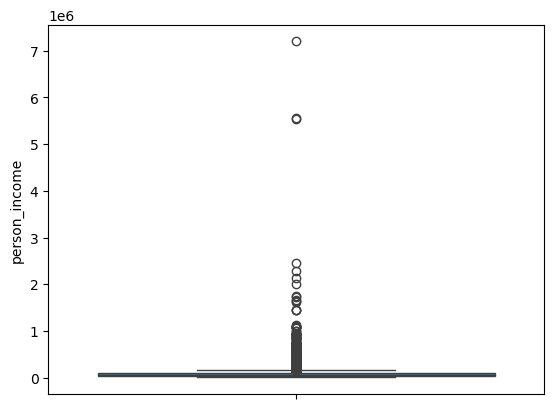

In [98]:
sns.boxplot(df['person_income'])

In [99]:
preprocessing=ColumnTransformer(transformers=[
    ('encoding',OneHotEncoder(dtype='int',sparse_output=False,handle_unknown='ignore'),cat_col),
    ('scaling',RobustScaler(),num_cat)
])
preprocessing

ColumnTransformer(transformers=[('encoding',
                                 OneHotEncoder(dtype='int',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')),
                                ('scaling', RobustScaler(),
                                 Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object'))])

In [100]:
preprocessing.fit_transform(xtrain,ytrain)

array([[ 1.        ,  0.        ,  0.        , ...,  0.25      ,
         1.        , -0.13235294],
       [ 0.        ,  1.        ,  0.        , ...,  0.33333333,
         0.        ,  0.27941176],
       [ 1.        ,  0.        ,  0.        , ..., -0.41666667,
         1.4       ,  0.63235294],
       ...,
       [ 1.        ,  0.        ,  1.        , ...,  0.5       ,
         1.        ,  0.17647059],
       [ 0.        ,  1.        ,  0.        , ..., -0.08333333,
        -0.2       , -0.52941176],
       [ 1.        ,  0.        ,  0.        , ..., -0.41666667,
        -0.2       ,  0.35294118]])

In [101]:
pipline=Pipeline(steps=[
    ('Prepro_obj',preprocessing),
    ('model',DecisionTreeClassifier())
])

In [102]:
pipline.fit(xtrain,ytrain)

Pipeline(steps=[('Prepro_obj',
                 ColumnTransformer(transformers=[('encoding',
                                                  OneHotEncoder(dtype='int',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')),
                                                 ('scaling', RobustScaler(),
                                                  Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object'))])),
                ('model', DecisionTreeClassifier())])

In [103]:
cv=GridSearchCV(estimator=pipline,param_grid={
    'model__criterion':['entropy','gini'],'model__max_depth':['None',10,50,100],'model__min_samples_leaf':[1,2,3,4,5],'model__min_samples_split':[2,5,10],'model__splitter':['best','random']},cv=5,scoring="f1")

In [104]:
cv.fit(xtrain,ytrain)

c:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
300 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
300 fits failed with the following error:
Traceback (most recent call last):
  File "c:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\anaconda\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\anaconda\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\an

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Prepro_obj',
                                        ColumnTransformer(transformers=[('encoding',
                                                                         OneHotEncoder(dtype='int',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')),
                                                                        ('scaling',
                                                                         RobustScaler(),
                                                                         Index(['person_age',...
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object'))])),
                                       ('model', DecisionTreeClassifier())]),
             param_grid={'model__criterion': ['entropy', 'gini'],
                         'model__max_depth': ['None', 10, 50, 100],
                         'model__min_samples_leaf': [1, 2, 3, 4, 5],
                         'model__min_samples_split': [2, 5, 10],
                         'model__splitter': ['best', 'random']},
             scoring='f1')

In [105]:
cv_model=cv.best_params_
cv_model

{'model__criterion': 'entropy',
 'model__max_depth': 10,
 'model__min_samples_leaf': 5,
 'model__min_samples_split': 2,
 'model__splitter': 'best'}

In [106]:
ytrain_pred=pipline.predict(xtrain)
ytest_pred=pipline.predict(xtest)

In [107]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28010
           1       1.00      1.00      1.00      7990

    accuracy                           1.00     36000
   macro avg       1.00      1.00      1.00     36000
weighted avg       1.00      1.00      1.00     36000



In [108]:
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      6990
           1       0.77      0.80      0.79      2010

    accuracy                           0.90      9000
   macro avg       0.86      0.87      0.86      9000
weighted avg       0.90      0.90      0.90      9000



In [109]:
cv_pred_xtrain=cv.predict(xtrain)
cv_pred_xtest=cv.predict(xtest)

In [110]:
print(classification_report(ytrain,cv_pred_xtrain))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96     28010
           1       0.92      0.75      0.83      7990

    accuracy                           0.93     36000
   macro avg       0.92      0.87      0.89     36000
weighted avg       0.93      0.93      0.93     36000



In [111]:
print(classification_report(ytest,cv_pred_xtest))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      6990
           1       0.89      0.73      0.80      2010

    accuracy                           0.92      9000
   macro avg       0.91      0.85      0.88      9000
weighted avg       0.92      0.92      0.92      9000

